# Delivery Time Prediction — Data Cleaning

**Steps (exactly):**
1. Drop specified columns
2. Drop rows with missing values
3. Clip target at p99
4. Log-transform heavy-tailed numeric features

**Output:** `train_clean.csv` / `test_clean.csv`

---
## 0. Setup

In [60]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

TARGET = 'delivery_time_days'

DROP_COLS = [ 
    'id',
    'order_id', 'customer_unique_id', 'product_id',
    'product_name_length', 'product_description_length',
    'product_length_cm', 'product_height_cm', 'product_width_cm', 
    'product_photos_qty'
]



print('Setup complete ✓')

Setup complete ✓


---
## 1. Load data

In [61]:
train = pd.read_csv('dataset/train.csv')
test  = pd.read_csv('dataset/test.csv')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')

Train : (85159, 26)
Test  : (15029, 25)


---
## 2. Drop columns

In [62]:
train = train.drop(columns=[c for c in DROP_COLS if c in train.columns])
test  = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')

Train : (85159, 16)
Test  : (15029, 15)


---
## 4. Clip target at p99

In [64]:
p99 = train[TARGET].quantile(0.99)
n_clipped = (train[TARGET] > p99).sum()

train[TARGET] = train[TARGET].clip(upper=p99)

print(f'p99 threshold : {p99:.2f} days')
print(f'Rows clipped  : {n_clipped} ({n_clipped / len(train) * 100:.2f}%)')
print(f'New max       : {train[TARGET].max():.2f} days')

p99 threshold : 47.20 days
Rows clipped  : 852 (1.00%)
New max       : 47.20 days


---
## 6. Validation

In [67]:
train=train.dropna()

assert train.isnull().sum().sum() == 0,           'Missing values in train!'
assert train[TARGET].max() <= p99,                'Target not clipped!'
assert np.isinf(train.select_dtypes(include=np.number).values).sum() == 0, 'Inf values in train!'

assert TARGET not in test.columns,                'Target leaking into test!'

print('All checks passed ✓')
print(f'\nFinal shapes — Train: {train.shape}  |  Test: {test.shape}')
print(f'Columns: {list(train.columns)}')

All checks passed ✓

Final shapes — Train: (83401, 16)  |  Test: (15029, 15)
Columns: ['customer_city', 'customer_lat', 'customer_lng', 'seller_id', 'seller_city', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'delivery_time_days']


---
## 7. Save

In [ ]:
import os
os.makedirs('dataset/processed', exist_ok=True)

train.to_csv('dataset/processed/train_clean.csv', index=False)
test.to_csv( 'dataset/processed/test_clean.csv',  index=False)

print('Saved train_clean.csv✓')
print('Saved test_clean.csv  ✓')

Saved train_clean.csv✓
Saved test_clean.csv  ✓


# Delivery Time Prediction — Feature Engineering

**Input:** `train_clean.csv` / `test_clean.csv`  
**Output:** `train_features.csv` / `test_features.csv`

**Features built:**
- `same_city` — seller and customer in same city
- `is_weekend` — order placed on Saturday or Sunday
- `purchase_month` — month of order placement
- `approval_lag_hours` — hours between purchase and approval
- `same_day_approval` — approved the same day as purchase
- `distance_km` — haversine distance between seller and customer
- `product_density` — product_weight_g / volume_cm3
- `seller_mean_delivery` — mean delivery time per seller
- `seller_pending_orders` — orders placed by same seller on same day

Categorical columns (`product_category_name_english`, `customer_city`, `seller_city`) are kept as-is and passed to LightGBM natively.

---
## 0. Setup

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TARGET = 'delivery_time_days'
CAT_COLS = ['product_category_name_english', 'customer_city', 'seller_city', 'order_purchase_timestamp', 'order_approved_at']

print('Setup complete ✓')

Setup complete ✓


---
## 1. Load cleaned data

In [116]:
train = pd.read_csv('dataset/processed/train_clean.csv')
test  = pd.read_csv('dataset/processed/test_clean.csv')

for col in ['order_purchase_timestamp', 'order_approved_at']:
    for df in (train, test):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

GLOBAL_MEAN = train[TARGET].mean()

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')

Train : (83401, 16)
Test  : (15029, 15)


---
## 2. Boolean — `same_city`

In [117]:
for df in (train, test):
    df['same_city'] = (
        df['customer_city'].str.lower().str.strip() ==
        df['seller_city'].str.lower().str.strip()
    ).astype(int)

print(f'same_city rate — train : {train["same_city"].mean()*100:.1f}%')
print(f'same_city rate — test  : {test["same_city"].mean()*100:.1f}%')

same_city rate — train : 4.9%
same_city rate — test  : 6.6%


---
## 3. Temporal — `is_weekend`, `purchase_month`

In [118]:
for df in (train, test):
    df['is_weekend']     = (df['order_purchase_timestamp'].dt.dayofweek >= 5).astype(int)
    df['purchase_month'] = df['order_purchase_timestamp'].dt.month

print(f'is_weekend rate — train : {train["is_weekend"].mean()*100:.1f}%')
print(f'purchase_month  — train : {train["purchase_month"].value_counts().sort_index().to_dict()}')

is_weekend rate — train : 23.0%
purchase_month  — train : {1: 7928, 2: 8236, 3: 9639, 4: 9281, 5: 10519, 6: 7462, 7: 3964, 8: 4274, 9: 4215, 10: 4867, 11: 7470, 12: 5546}


---
## 4. Approval — `approval_lag_hours`, `same_day_approval`

In [119]:
for df in (train, test):
    lag = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
    df['approval_lag_hours'] = lag.clip(lower=0)
    df['same_day_approval']  = (
        df['order_purchase_timestamp'].dt.date ==
        df['order_approved_at'].dt.date
    ).astype(int)

print('approval_lag_hours — train:')
print(train['approval_lag_hours'].describe().round(2).to_string())
print(f'\nsame_day_approval rate — train : {train["same_day_approval"].mean()*100:.1f}%')

approval_lag_hours — train:
count    83401.00
mean        10.16
std         20.50
min          0.00
25%          0.00
50%          1.00
75%         14.00
max        741.00

same_day_approval rate — train : 69.6%


---
## 5. Distance — `distance_km`

In [120]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

for df in (train, test):
    df['distance_km'] = haversine_km(
        df['customer_lat'], df['customer_lng'],
        df['seller_lat'],   df['seller_lng']
    )

print('distance_km — train:')
print(train['distance_km'].describe().round(1).to_string())

distance_km — train:
count    83401.0
mean       606.6
std        592.0
min          0.0
25%        205.9
50%        440.8
75%        802.6
max       5338.6


---
## 6. Product density — `product_density`

In [121]:
for df in (train, test):
    df['product_density'] = (
        df['product_weight_g'] / df['volume_cm3'].replace(0, np.nan)
    )
    df['product_density'].fillna(df['product_density'].median(), inplace=True)

print('product_density — train:')
print(train['product_density'].describe().round(4).to_string())

product_density — train:
count    83401.0000
mean         0.1926
std          0.7004
min          0.0003
25%          0.0672
50%          0.1126
75%          0.1937
max         65.9091


---
## 7. Seller aggregations

> ⚠️ Computed on the full training set. Recompute inside each CV fold in the modelling notebook to avoid target leakage.

### 7a. `seller_mean_delivery`

In [122]:
seller_mean = (
    train.groupby('seller_id')[TARGET]
         .mean()
         .rename('seller_mean_delivery')
         .reset_index()
)

train = train.merge(seller_mean, on='seller_id', how='left')
test  = test.merge(seller_mean,  on='seller_id', how='left')

train['seller_mean_delivery'].fillna(GLOBAL_MEAN, inplace=True)
test['seller_mean_delivery'].fillna(GLOBAL_MEAN,  inplace=True)

unseen = (~test['seller_id'].isin(train['seller_id'])).sum()
print(f'Unseen sellers in test filled with global mean: {unseen}')
print(train['seller_mean_delivery'].describe().round(2).to_string())

Unseen sellers in test filled with global mean: 1671
count    83401.00
mean        13.05
std          3.03
min          1.04
25%         11.08
50%         12.87
75%         14.74
max         47.22


### 7b. `seller_pending_orders`

In [123]:
for df in (train, test):
    df['_purchase_date'] = df['order_purchase_timestamp'].dt.date

seller_daily = (
    train.groupby(['seller_id', '_purchase_date'])
         .size()
         .rename('seller_pending_orders')
         .reset_index()
)

train = train.merge(seller_daily, on=['seller_id', '_purchase_date'], how='left')
test  = test.merge(seller_daily,  on=['seller_id', '_purchase_date'], how='left')

train['seller_pending_orders'].fillna(1, inplace=True)
test['seller_pending_orders'].fillna(1,  inplace=True)

for df in (train, test):
    df.drop(columns=['_purchase_date'], inplace=True)

print('seller_pending_orders — train:')
print(train['seller_pending_orders'].describe().round(2).to_string())

seller_pending_orders — train:
count    83401.00
mean         2.60
std          3.84
min          1.00
25%          1.00
50%          1.00
75%          3.00
max         78.00


---
## 8. Cast categoricals for LightGBM

In [124]:
for col in CAT_COLS:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

print(f'Cast to category: {CAT_COLS}')

Cast to category: ['product_category_name_english', 'customer_city', 'seller_city', 'order_purchase_timestamp', 'order_approved_at']


---
## 9. Drop raw columns

In [ ]:
COLS_TO_DROP = ['seller_ids'                      # → seller_mean_delivery, seller_pending_orders
]

train = train.drop(columns=[c for c in COLS_TO_DROP if c in train.columns])
test  = test.drop(columns=[c for c in COLS_TO_DROP if c in test.columns])

feature_cols = [c for c in train.columns if c != TARGET]
test = test[feature_cols]

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')

Train : (83401, 24)
Test  : (15029, 23)

Features (23): ['customer_city', 'customer_lat', 'customer_lng', 'seller_city', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'same_city', 'is_weekend', 'purchase_month', 'approval_lag_hours', 'same_day_approval', 'distance_km', 'product_density', 'seller_mean_delivery', 'seller_pending_orders']


---
## 10. Validation

In [126]:
assert train.isnull().sum().sum() == 0,          'Missing values in train!'
assert test.isnull().sum().sum()  == 0,          'Missing values in test!'
assert TARGET not in test.columns,               'Target leaking into test!'
assert list(feature_cols) == list(test.columns), 'Feature mismatch!'
assert np.isinf(train.select_dtypes(include=np.number).values).sum() == 0, 'Inf in train!'
assert np.isinf(test.select_dtypes(include=np.number).values).sum()  == 0, 'Inf in test!'

print('All validation checks passed ✓')
print(f'Test rows preserved: {len(test):,}')

All validation checks passed ✓
Test rows preserved: 15,029


---
## 11. Correlation matrix (numeric features only)

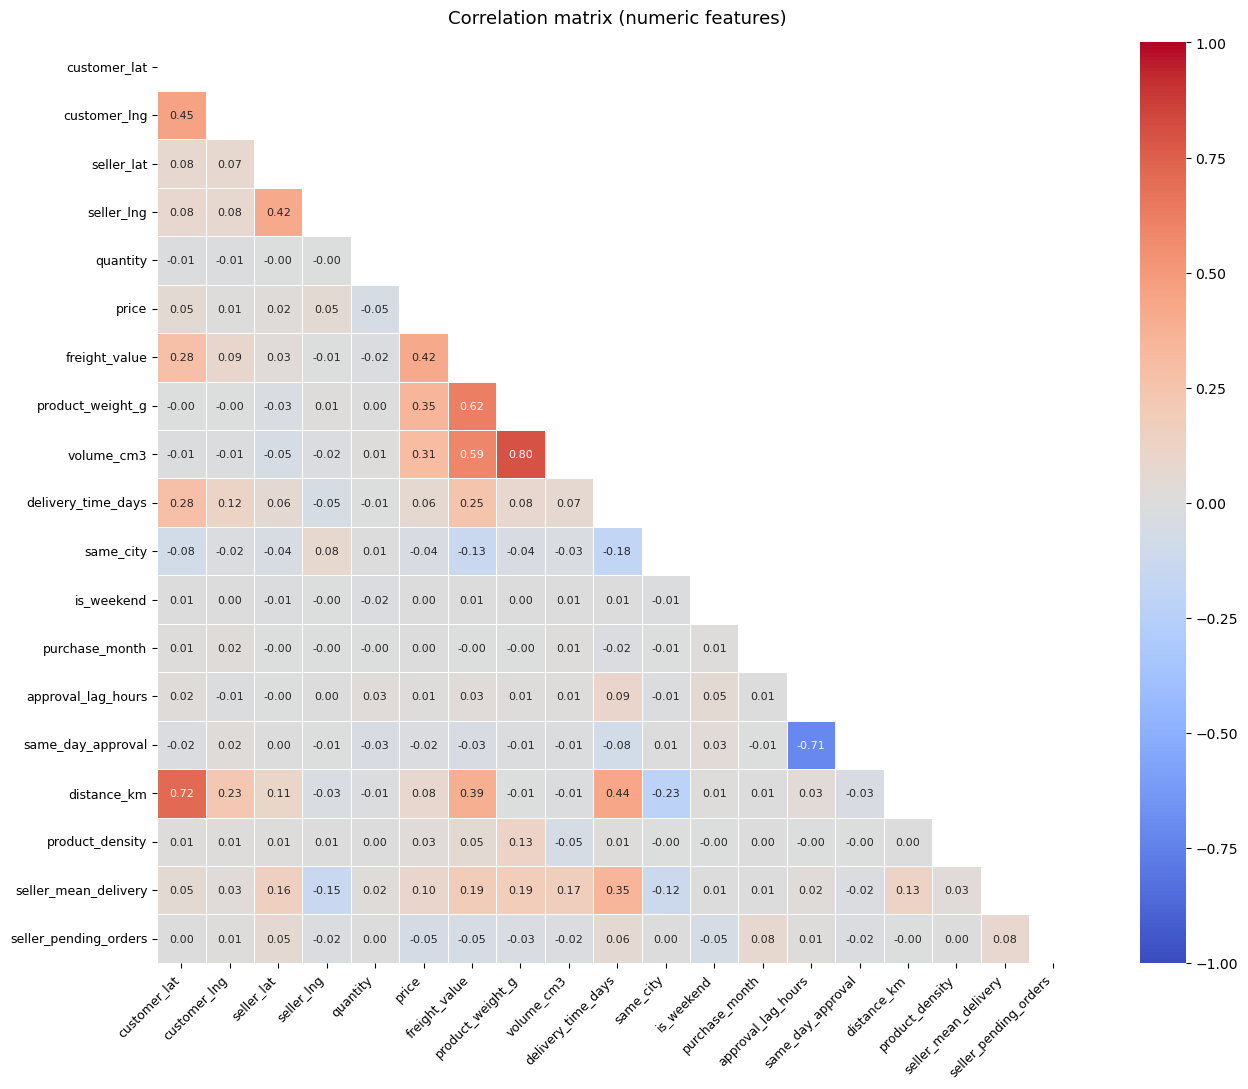


Correlations with target:


,delivery_time_days
distance_km,0.435
seller_mean_delivery,0.349
customer_lat,0.280
freight_value,0.252
customer_lng,0.123
approval_lag_hours,0.095
product_weight_g,0.082
volume_cm3,0.070
price,0.063
seller_pending_orders,0.062


In [127]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 8}, cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True, ax=ax
)
ax.set_title('Correlation matrix (numeric features)', fontsize=13, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
import os; os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCorrelations with target:')
display(
    corr[[TARGET]].drop(TARGET)
                  .sort_values(TARGET, ascending=False)
                  .round(3)
)

---
## 12. Save

In [128]:
import os
os.makedirs('dataset/processed', exist_ok=True)

train.to_csv('dataset/processed/train_features.csv', index=False)
test.to_csv( 'dataset/processed/test_features.csv',  index=False)

print('Saved train_features.csv ✓')
print('Saved test_features.csv  ✓')

Saved train_features.csv ✓
Saved test_features.csv  ✓


# Delivery Time Prediction — Modelling (LightGBM)

**Input:** `train_features.csv` / `test_features.csv`  
**Model:** LightGBM with native categorical handling  
**Metric:** MAE

---
## 0. Setup

In [38]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

SEED     = 42
TARGET   = 'delivery_time_days'
N_FOLDS  = 5
CAT_COLS = ['product_category_name_english', 'customer_city', 'seller_city']

print('Setup complete ✓')

Setup complete ✓


---
## 1. Load data

In [39]:
train = pd.read_csv('dataset/processed/train_features.csv')
test  = pd.read_csv('dataset/processed/test_features.csv')

train = train.drop(columns=['same_city', 'quantity', 'same_day_approval', 'is_weekend', 'approval_lag_hours','seller_pending_orders'])
test = test.drop(columns=['same_city', 'quantity', 'same_day_approval', 'is_weekend', 'approval_lag_hours','seller_pending_orders'])

# Restore category dtype (lost on CSV save/load)
for col in CAT_COLS:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

X      = train.drop(columns=[TARGET])
y      = train[TARGET]
X_test = test.copy()

naive_mae = mean_absolute_error(y, np.full(len(y), y.median()))

print(f'Train  : {X.shape}')
print(f'Test   : {X_test.shape}')
print(f'Naive baseline MAE : {naive_mae:.4f}')
print(f'Features : {list(X.columns)}')

Train  : (83401, 17)
Test   : (15029, 17)
Naive baseline MAE : 6.1846
Features : ['customer_city', 'customer_lat', 'customer_lng', 'seller_city', 'seller_lat', 'seller_lng', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'purchase_month', 'distance_km', 'product_density', 'seller_mean_delivery']


---
## 2. Cross-validation

In [40]:

X["order_purchase_timestamp"] = pd.to_datetime(X["order_purchase_timestamp"]).astype("int64")
X["order_approved_at"] = pd.to_datetime(X["order_approved_at"]).astype("int64")

X_test["order_purchase_timestamp"] = pd.to_datetime(X_test["order_purchase_timestamp"]).astype("int64")
X_test["order_approved_at"] = pd.to_datetime(X_test["order_approved_at"]).astype("int64")

params = {
    'objective'        : 'mae',
    'metric'           : 'mae',
    'n_estimators'     : 3000,
    'learning_rate'    : 0.02,
    'num_leaves'       : 31,
    'min_child_samples': 50,
    'subsample'        : 0.7,
    'colsample_bytree' : 0.7,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : SEED,
    'verbose'          : -1,
}

kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_maes  = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=CAT_COLS,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    oof_preds[val_idx]  = model.predict(X_val)
    test_preds         += model.predict(X_test) / N_FOLDS

    mae = mean_absolute_error(y_val, oof_preds[val_idx])
    fold_maes.append(mae)
    print(f'Fold {fold} — MAE: {mae:.4f}  |  best iter: {model.best_iteration_}')

cv_mae = mean_absolute_error(y, oof_preds)
print(f'\nCV MAE (OOF)        : {cv_mae:.4f}')
print(f'Std across folds    : {np.std(fold_maes):.4f}')
print(f'Improvement vs naive: {naive_mae - cv_mae:.4f} days')

Fold 1 — MAE: 4.2070  |  best iter: 2996
Fold 2 — MAE: 4.2091  |  best iter: 3000
Fold 3 — MAE: 4.2202  |  best iter: 2999
Fold 4 — MAE: 4.2813  |  best iter: 2989
Fold 5 — MAE: 4.2193  |  best iter: 2989

CV MAE (OOF)        : 4.2274
Std across folds    : 0.0275
Improvement vs naive: 1.9572 days


---
## 3. Feature importance

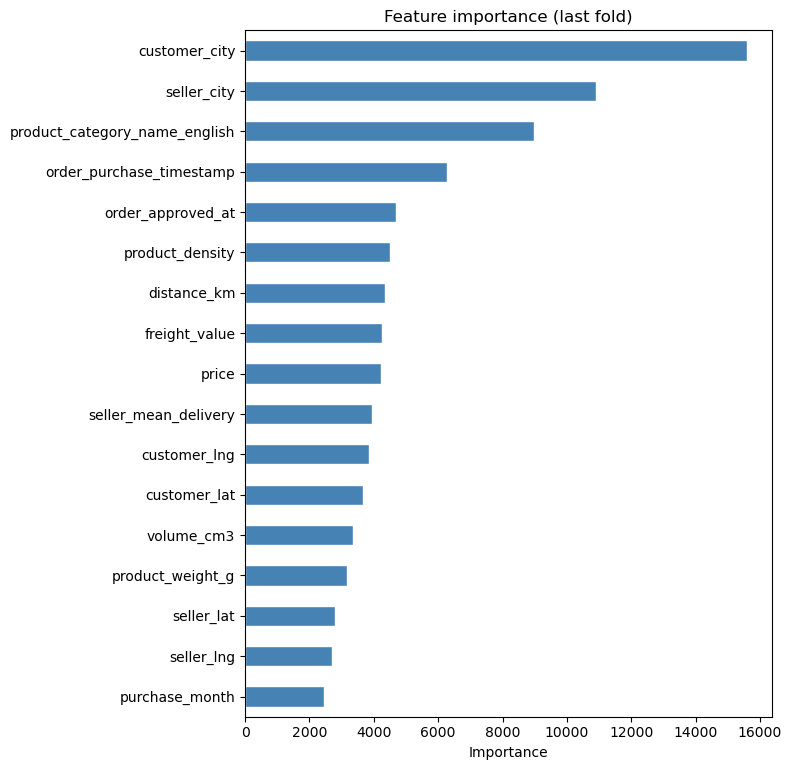

In [41]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, len(importance) * 0.4 + 1))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature importance (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 4. Save submission

In [42]:
os.makedirs('submissions', exist_ok=True)

assert test_preds.max() > 0,         'Predictions are all zeros!'
assert len(test_preds) == len(test), 'Row count mismatch!'

submission = pd.DataFrame({
    'id'                : range(len(test_preds)),
    'delivery_time_days': test_preds
})

submission.to_csv('submissions/submission_lgbm_v99.csv', index=False)

print(f'Submission saved ✓  —  {len(submission):,} rows')
print(submission['delivery_time_days'].describe().round(2))

Submission saved ✓  —  15,029 rows
count    15029.00
mean         7.76
std          3.96
min          1.18
25%          5.20
50%          7.07
75%          9.70
max         31.10
Name: delivery_time_days, dtype: float64
